<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:177: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:177: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_32218/3149201816.py:24: SyntaxWarning: invalid escape sequence '\i'
  """
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_32218/3149201816.py:177: SyntaxWarning: invalid escape sequence '\p'
  """


Matrix Fisher sampling on SO(3) via Independence MH
Singular values in proper SVD s = [10.  6.  2.]
Bingham parameters a = [ 18.   2.  -6. -14.]
Shifted Bingham parameters z = [  0. -16. -24. -32.]
ACG kappa = [ 1. 17. 25. 33.]
Acceptance rate = 0.4697
Mean geodesic distance d(R0, I) = 0.5038 rad
Std  geodesic distance d(R0, I) = 0.2311 rad
Stored samples = 2500


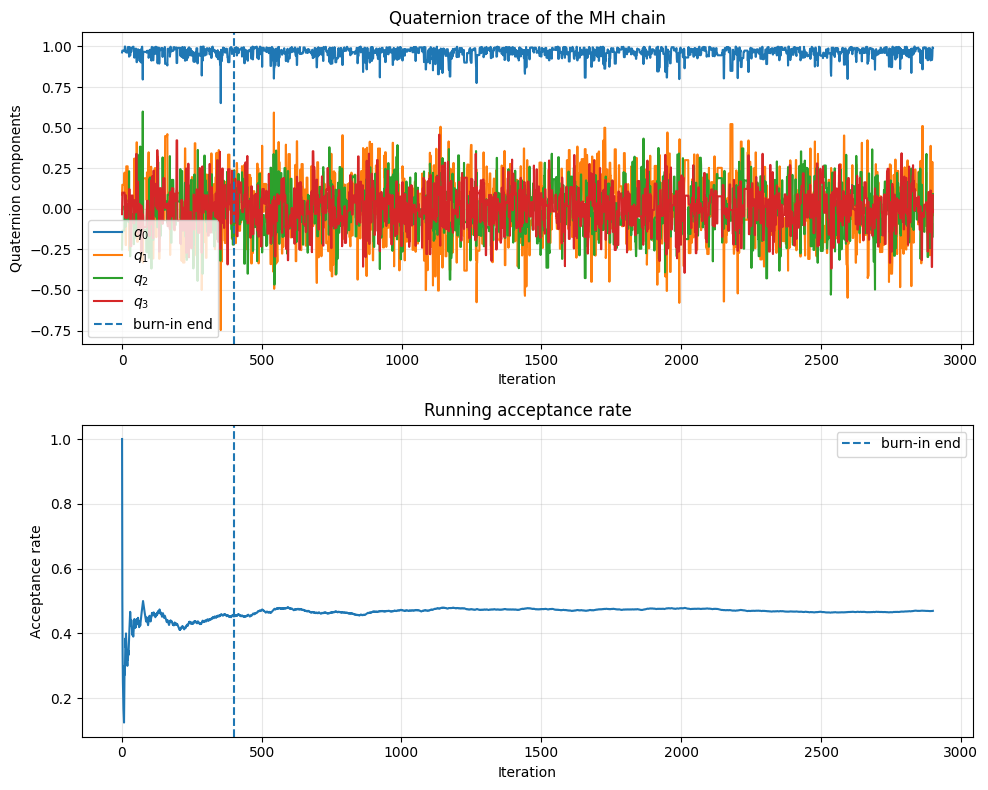

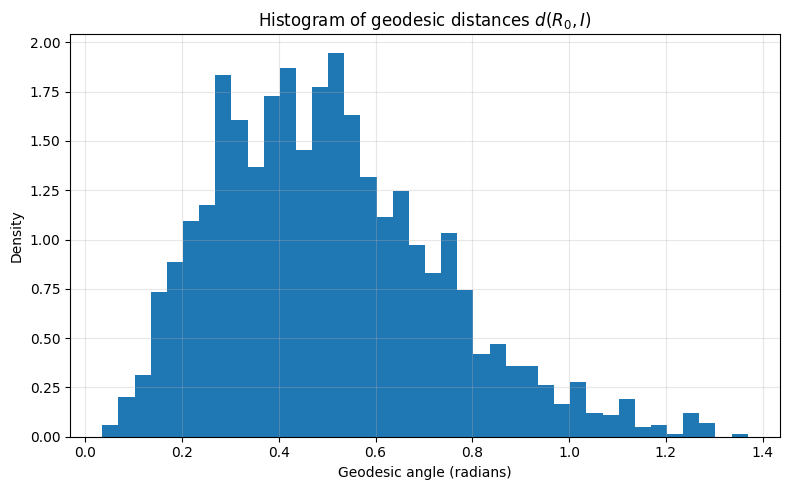

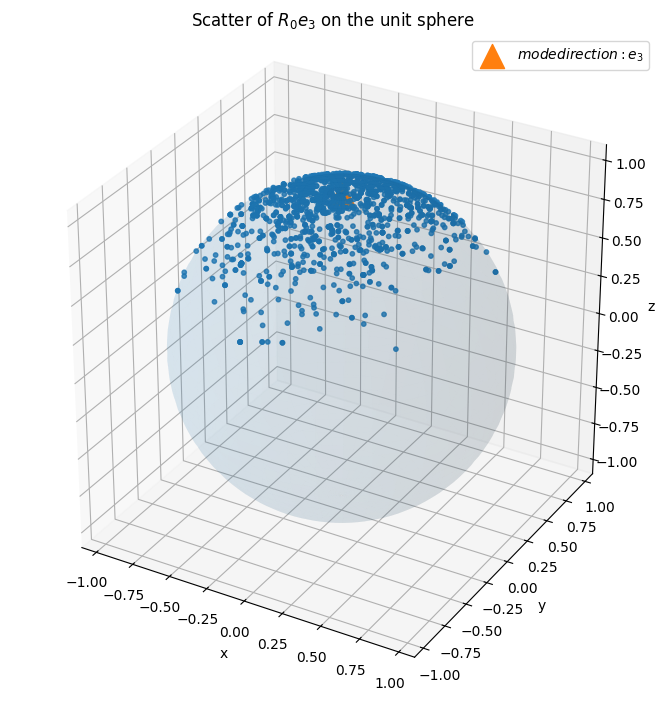

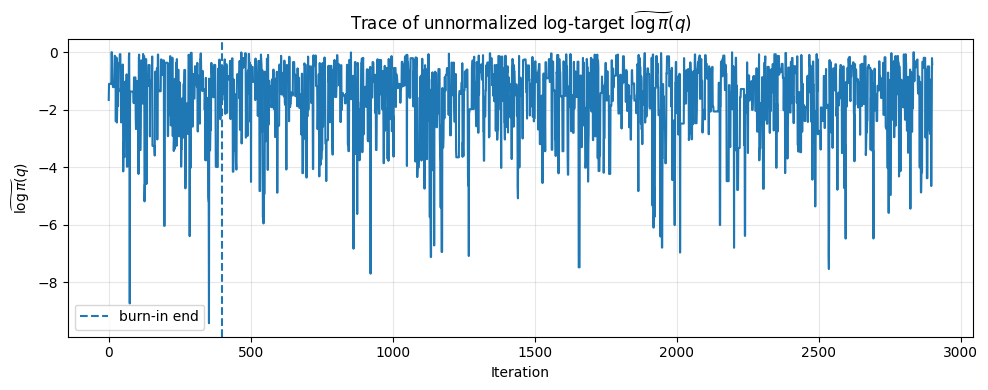

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ============================================================
# 1. base tool functions
# ============================================================

def canonicalize_quaternion(q: np.ndarray) -> np.ndarray:
    """
    willunitquaternionestablish sign convention：
    if q0 < 0，then multiply -1。
    this does not changeforshouldrotationmatrix，because q and -q represents the samerotation。
    """
    q = np.asarray(q, dtype=float)
    q = q / np.linalg.norm(q)
    if q[0] < 0:
        q = -q
    return q


def quat_to_rot(q: np.ndarray) -> np.ndarray:
    """
    scalaratunit beforequaternion q = [q0, q1, q2, q3]^T
    convert torotationmatrix R \in SO(3)
    """
    q = canonicalize_quaternion(q)
    q0, q1, q2, q3 = q

    R = np.array([
        [q0*q0 + q1*q1 - q2*q2 - q3*q3,  2*(q1*q2 - q0*q3),              2*(q1*q3 + q0*q2)],
        [2*(q1*q2 + q0*q3),              q0*q0 - q1*q1 + q2*q2 - q3*q3,  2*(q2*q3 - q0*q1)],
        [2*(q1*q3 - q0*q2),              2*(q2*q3 + q0*q1),              q0*q0 - q1*q1 - q2*q2 + q3*q3]
    ], dtype=float)
    return R


def axis_angle_to_rot(axis: np.ndarray, angle: float) -> np.ndarray:
    """
    Rodrigues formula：from axis-angletorotationmatrix。
    axis: 3dimensionrotationaxis
    angle: rotationangle（radian）
    """
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c = np.cos(angle)
    s = np.sin(angle)
    C = 1.0 - c

    R = np.array([
        [c + x*x*C,     x*y*C - z*s, x*z*C + y*s],
        [y*x*C + z*s,   c + y*y*C,   y*z*C - x*s],
        [z*x*C - y*s,   z*y*C + x*s, c + z*z*C]
    ], dtype=float)
    return R


def geodesic_distance_so3(R1: np.ndarray, R2: np.ndarray = None) -> float:
    """
    SO(3) ontestlocal distance：
        d(R1, R2) = arccos((trace(R1^T R2)-1)/2)
    """
    if R2 is None:
        R2 = np.eye(3)
    c = (np.trace(R1.T @ R2) - 1.0) / 2.0
    c = np.clip(c, -1.0, 1.0)
    return float(np.arccos(c))


# ============================================================
# 2. Algorithm 1 indetailed math steps
# ============================================================

def proper_svd(F: np.ndarray):
    """
    robust proper SVD:
        F = U S V^T,
        U, V in SO(3),
        S = diag(s1, s2, s3)
    itsin s3 allow sign。

    more robust，becauseit respectivelycorrection U0 and V0 rowcolumnformula，
    rather thanonlysee det(U0 V0^T)。
    """
    U0, sigma, Vt0 = np.linalg.svd(F)
    V0 = Vt0.T

    # willnumericalrowcolumncompressed formula ±1
    sign_u = 1.0 if np.linalg.det(U0) > 0 else -1.0
    sign_v = 1.0 if np.linalg.det(V0) > 0 else -1.0

    Du = np.diag([1.0, 1.0, sign_u])
    Dv = np.diag([1.0, 1.0, sign_v])

    # correctionafter U, V all fallat SO(3)
    U = U0 @ Du
    V = V0 @ Dv

    # maintain F = U S V^T
    Sigma = np.diag(sigma)
    S = Du @ Sigma @ Dv
    s = np.diag(S).copy()

    # numerical check
    tol = 1e-8
    if np.linalg.det(U) < 1 - tol or np.linalg.det(V) < 1 - tol:
        raise ValueError("proper SVD failed: U or V is not numerically in SO(3).")

    # then check if truly reconstructed
    err = np.linalg.norm(F - U @ S @ V.T, ord='fro')
    if err > 1e-8 * (1.0 + np.linalg.norm(F, ord='fro')):
        raise ValueError(f"proper SVD reconstruction failed, error = {err:.3e}")

    return U, S, V, s


def mf_diag_to_bingham_params(s: np.ndarray):
    """
    willnormalize Matrix Fisher parameter S=diag(s1,s2,s3)
    convert to S^3 on Bingham distributionparameter。

    first define:
        a0 = s1+s2+s3
        a1 = s1-s2-s3
        a2 = -s1+s2-s3
        a3 = -s1-s2+s3

    for numerical stability，then dotranslation:
        z_j = a_j - max(a)
    thus z_j <= 0
    """
    s1, s2, s3 = s
    a = np.array([
        s1 + s2 + s3,
        s1 - s2 - s3,
        -s1 + s2 - s3,
        -s1 - s2 + s3
    ], dtype=float)

    z = a - np.max(a)
    return a, z


def build_acg_shape(z: np.ndarray, c: float = 1.0):
    """
    construct ACG proposal  shape matrix K:
        K = diag(kappa_0, ..., kappa_3),
        kappa_j = c - z_j > 0

    proposal via y ~ N(0, K^{-1})，renormalize q = y / ||y|| generate。
    """
    z = np.asarray(z, dtype=float)
    kappa = c - z
    if np.any(kappa <= 0):
        raise ValueError("ACG shape construction failed: some kappa_j <= 0. Try a larger c.")

    K = np.diag(kappa)
    Sigma_g = np.diag(1.0 / kappa)
    return K, Sigma_g, kappa


def sample_acg(Sigma_g: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """
    from ACG proposal insample：
        y ~ N(0, Sigma_g)
        q = y / ||y||
    """
    y = rng.multivariate_normal(mean=np.zeros(4), cov=Sigma_g)
    q = y / np.linalg.norm(y)
    q = canonicalize_quaternion(q)
    return q


def log_target_bingham(q: np.ndarray, z: np.ndarray) -> float:
    """
    unnormalized log-target:
        log \tilde{\pi}(q) = sum_j z_j q_j^2
    """
    q = canonicalize_quaternion(q)
    return float(np.dot(z, q * q))


def log_proposal_acg(q: np.ndarray, K: np.ndarray) -> float:
    """
    unnormalized log-proposal:
        log \tilde{g}(q) = -2 log(q^T K q)
    """
    q = canonicalize_quaternion(q)
    val = float(q @ K @ q)
    return float(-2.0 * np.log(val))


# ============================================================
# 3. Matrix Fisher on SO(3) via Independence MH
# ============================================================

def sample_mf_so3_independence_mh(
    F: np.ndarray,
    N: int = 2000,
    burnin: int = 300,
    thin: int = 1,
    c: float = 1.0,
    seed: int = 42,
):
    """
    according to Algorithm 1 performsample：
      1) proper SVD
      2) constructequivalent Bingham target on S^3
      3) construct ACG proposal
      4) use Independence MH
      5) log-domain acceptance criterion
      6) burn-in + thinning
      7) q -> R0 -> R

    return:
        a dict，containsampleresultandvisualizerequiredallintemporal quantity。
    """
    rng = np.random.default_rng(seed)

    # ---------------------------
    # Step 1: proper SVD
    # ---------------------------
    U, S, V, s = proper_svd(F)

    # ---------------------------
    # Step 2: Bingham parameter
    # ---------------------------
    a, z = mf_diag_to_bingham_params(s)

    # ---------------------------
    # Step 3: ACG proposal
    # ---------------------------
    K, Sigma_g, kappa = build_acg_shape(z, c=c)

    # ---------------------------
    # Step 4: initialize q^(0) ~ g(q)
    # ---------------------------
    q_current = sample_acg(Sigma_g, rng)
    log_pi_current = log_target_bingham(q_current, z)
    log_g_current = log_proposal_acg(q_current, K)

    # for saving full chain and diagnostics
    chain_q = [q_current.copy()]
    chain_log_pi = [log_pi_current]
    accepted_flags = []

    # for saving finalsamplethis
    stored_q = []
    stored_R0 = []
    stored_R = []
    stored_iter = []

    t = 0
    while len(stored_R) < N:
        # ---------------------------
        # Step 5: propose q' ~ g(q)
        # ---------------------------
        q_prop = sample_acg(Sigma_g, rng)
        log_pi_prop = log_target_bingham(q_prop, z)
        log_g_prop = log_proposal_acg(q_prop, K)

        # ---------------------------
        # Step 6: log-domain acceptance rate
        # Delta = log pi(q') - log pi(q^k) + log g(q^k) - log g(q')
        # acceptance condition: log u <= min(0, Delta)
        # ---------------------------
        Delta = log_pi_prop - log_pi_current + log_g_current - log_g_prop
        u = rng.random()

        if np.log(u) <= min(0.0, Delta):
            q_current = q_prop
            log_pi_current = log_pi_prop
            log_g_current = log_g_prop
            accepted = 1
        else:
            accepted = 0

        t += 1
        accepted_flags.append(accepted)
        chain_q.append(q_current.copy())
        chain_log_pi.append(log_pi_current)

        # ---------------------------
        # Step 7: burn-in + thinning
        # ---------------------------
        if t > burnin and ((t - burnin) % thin == 0):
            R0 = quat_to_rot(q_current)
            R = U @ R0 @ V.T

            stored_q.append(q_current.copy())
            stored_R0.append(R0.copy())
            stored_R.append(R.copy())
            stored_iter.append(t)

    results = {
        "F": F,
        "U": U,
        "S": S,
        "V": V,
        "s": s,
        "a": a,
        "z": z,
        "K": K,
        "Sigma_g": Sigma_g,
        "kappa": kappa,
        "chain_q": np.array(chain_q),
        "chain_log_pi": np.array(chain_log_pi),
        "accepted_flags": np.array(accepted_flags),
        "stored_q": np.array(stored_q),
        "stored_R0": np.array(stored_R0),
        "stored_R": np.array(stored_R),
        "stored_iter": np.array(stored_iter),
        "acceptance_rate": float(np.mean(accepted_flags)) if len(accepted_flags) > 0 else 0.0,
        "burnin": burnin,
        "thin": thin,
        "N": N,
        "c": c,
        "seed": seed,
    }
    return results


# ============================================================
# 4. visualizefunction
# ============================================================

def plot_unit_sphere(ax, alpha=0.08):
    """
    at 3D coordinateaxisondrawunit sphere，for showing R0 e3 fallpointdistribution。
    """
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 40)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, linewidth=0, antialiased=True, alpha=alpha)


def visualize_mf_sampling(results: dict, max_scatter_points: int = 1500):
    """
    forsampleresultperformvisualize：
    1. quaternionchain trace
    2. running acceptance rate
    3. normalizesamplethis R0 tounitmatrix I testlocal anglehistogram
    4. R0 e3 atsphereonscatter plot

    hereshownormalizesamplethis R0，becausenormalizeposterior targetdistributionforshould MF(S)。
    """
    chain_q = results["chain_q"]
    accepted_flags = results["accepted_flags"]
    stored_R0 = results["stored_R0"]
    burnin = results["burnin"]

    # ---------------------------
    # figure 1: quaternion trace + acceptance
    # ---------------------------
    fig1, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

    iters_chain = np.arange(chain_q.shape[0])
    axs[0].plot(iters_chain, chain_q[:, 0], label=r"$q_0$")
    axs[0].plot(iters_chain, chain_q[:, 1], label=r"$q_1$")
    axs[0].plot(iters_chain, chain_q[:, 2], label=r"$q_2$")
    axs[0].plot(iters_chain, chain_q[:, 3], label=r"$q_3$")
    axs[0].axvline(burnin, linestyle="--", linewidth=1.5, label="burn-in end")
    axs[0].set_title("Quaternion trace of the MH chain")
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel("Quaternion components")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    running_acc = np.cumsum(accepted_flags) / np.arange(1, len(accepted_flags) + 1)
    axs[1].plot(np.arange(1, len(accepted_flags) + 1), running_acc)
    axs[1].axvline(burnin, linestyle="--", linewidth=1.5, label="burn-in end")
    axs[1].set_title("Running acceptance rate")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Acceptance rate")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()

    # ---------------------------
    # figure 2: normalizesamplethistestlocal angledistribution
    # ---------------------------
    geodesic_angles = np.array([geodesic_distance_so3(R0, np.eye(3)) for R0 in stored_R0])

    fig2, ax2 = plt.subplots(figsize=(8, 5))
    ax2.hist(geodesic_angles, bins=40, density=True)
    ax2.set_title(r"Histogram of geodesic distances $d(R_0, I)$")
    ax2.set_xlabel(r"Geodesic angle (radians)")
    ax2.set_ylabel("Density")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()

    # ---------------------------
    # figure 3: will R0 e3 projecttosphereon
    # e3 = [0,0,1]^T，therefore R0 e3 is R0 thirdcolumn
    # ---------------------------
    pts = stored_R0[:, :, 2]
    if pts.shape[0] > max_scatter_points:
        idx = np.linspace(0, pts.shape[0] - 1, max_scatter_points).astype(int)
        pts = pts[idx]

    fig3 = plt.figure(figsize=(8, 7))
    ax3 = fig3.add_subplot(111, projection="3d")
    plot_unit_sphere(ax3, alpha=0.08)
    ax3.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=10, alpha=0.8)

    
    # plotreferencepoint e3
    ax3.scatter([0], [0], [1], s=300, marker="^", label=r"$mode direction:e_3$")
    ax3.set_title(r"Scatter of $R_0 e_3$ on the unit sphere")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_zlabel("z")
    ax3.legend()

    # maintainsphereratioexample consistent
    ax3.set_box_aspect((1, 1, 1))
    lim = 1.1
    ax3.set_xlim([-lim, lim])
    ax3.set_ylim([-lim, lim])
    ax3.set_zlim([-lim, lim])

    plt.tight_layout()

    # ---------------------------
    # figure 4: log-target trace
    # ---------------------------
    fig4, ax4 = plt.subplots(figsize=(10, 4))
    ax4.plot(np.arange(len(results["chain_log_pi"])), results["chain_log_pi"])
    ax4.axvline(burnin, linestyle="--", linewidth=1.5, label="burn-in end")
    ax4.set_title(r"Trace of unnormalized log-target $\widetilde{\log \pi}(q)$")
    ax4.set_xlabel("Iteration")
    ax4.set_ylabel(r"$\widetilde{\log \pi}(q)$")
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()


# ============================================================
# 5. can run directlyrowexample
# ============================================================

def main():
    """
    heregiveacan run directlyrowexample。
    canput F replace with any desiredtest Matrix Fisher parameter。
    """

    # --------------------------------------------------------
    # constructaexample F = U S V^T
    # herespecially chooseanon-trivial U, V，convenienttestgeneral case
    # --------------------------------------------------------
    U_true = axis_angle_to_rot(np.array([1.0, 0.0, 0.0]), np.deg2rad(25.0))
    V_true = axis_angle_to_rot(np.array([0.0, 1.0, 1.0]), np.deg2rad(-35.0))
    S_true = np.diag([10.0, 6.0, 2.0])

    F = U_true @ S_true @ V_true.T

    # --------------------------------------------------------
    # runrow Algorithm 1
    # --------------------------------------------------------
    results = sample_mf_so3_independence_mh(
        F=F,
        N=2500,       # finally keepsamplethisnumber
        burnin=400,   # burn-in length
        thin=1,       # thinning interval；ifdo not want thinning，then set to 1
        c=1.0,        # ACG shape translationparameter
        seed=123
    )

    # --------------------------------------------------------
    # print key info
    # --------------------------------------------------------
    print("=" * 70)
    print("Matrix Fisher sampling on SO(3) via Independence MH")
    print("=" * 70)
    print("Singular values in proper SVD s =", results["s"])
    print("Bingham parameters a =", results["a"])
    print("Shifted Bingham parameters z =", results["z"])
    print("ACG kappa =", results["kappa"])
    print(f"Acceptance rate = {results['acceptance_rate']:.4f}")

    # statisticsnormalizesamplethis R0 to I testlocal angle
    angles = np.array([geodesic_distance_so3(R0, np.eye(3)) for R0 in results["stored_R0"]])
    print(f"Mean geodesic distance d(R0, I) = {angles.mean():.4f} rad")
    print(f"Std  geodesic distance d(R0, I) = {angles.std():.4f} rad")
    print(f"Stored samples = {results['stored_R'].shape[0]}")
    print("=" * 70)

    # --------------------------------------------------------
    # visualize
    # --------------------------------------------------------
    visualize_mf_sampling(results, max_scatter_points=1500)


if __name__ == "__main__":
    main()

In [2]:
rng = np.random.default_rng(0)
F_test = rng.normal(size=(3, 3))

U, S, V, s = proper_svd(F_test)

print("det(U) =", np.linalg.det(U))
print("det(V) =", np.linalg.det(V))
print("reconstruction error =", np.linalg.norm(F_test - U @ S @ V.T, ord='fro'))
print("s =", s)

det(U) = 0.9999999999999994
det(V) = 0.9999999999999996
reconstruction error = 1.4062520637840194e-15
s = [1.81925125 0.73918354 0.32962399]


In [3]:
# ============================================================
# 6. moresamplevisualize
# ============================================================

def random_rotation(rng: np.random.Generator) -> np.ndarray:
    """
    generatearandomrotationmatrix Q \in SO(3)。
    use QR decompositiongenerate Haar-like randomrotation。
    """
    A = rng.normal(size=(3, 3))
    Q, _ = np.linalg.qr(A)
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1.0
    return Q


def apply_rotations_to_vector(Rs: np.ndarray, v: np.ndarray) -> np.ndarray:
    """
    for batch rotationsmatrix Rs (shape = [N, 3, 3])，calculate Rs @ v。
    return shape = [N, 3]。
    """
    v = np.asarray(v, dtype=float)
    return np.einsum("nij,j->ni", Rs, v)


def rough_ess_1d(x: np.ndarray, max_lag: int = 200) -> float:
    """
    rough estimatedimensiontime sequencecolumn ESS（validsamplethisquantity）。
    hereusesimple autophaserelevant integral approximation。
    note：this is diagnostic quantity，not strict statistical inference tool。
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 5:
        return float(n)

    x = x - np.mean(x)
    var = np.var(x)
    if var < 1e-14:
        return float(n)

    # autophaserelated function
    acf = []
    for lag in range(1, min(max_lag, n - 1) + 1):
        c = np.dot(x[:-lag], x[lag:]) / (n - lag)
        rho = c / var
        # encountertonon-positive autophaserelated truncation
        if rho <= 0:
            break
        acf.append(rho)

    tau_int = 1.0 + 2.0 * np.sum(acf)
    ess = n / tau_int
    return float(max(1.0, min(n, ess)))


def acceptance_quality_label(acc_rate: float) -> str:
    """
    based on acceptance rategivearough label。
    """
    if acc_rate < 0.05:
        return "poor"
    elif acc_rate < 0.15:
        return "marginal"
    elif acc_rate < 0.30:
        return "usable"
    elif acc_rate < 0.60:
        return "good"
    else:
        return "very good"


def plot_sphere_scatter(ax, pts: np.ndarray, title: str,
                        mode_point: np.ndarray = None,
                        max_points: int = 1200,
                        marker_size: int = 10):
    """
    atunit sphereondrawscatterpoint。
    pts: shape = [N, 3]
    mode_point: optional，plot mode forshoulddirectionpoint
    """
    plot_unit_sphere(ax, alpha=0.08)

    pts = np.asarray(pts, dtype=float)
    if pts.shape[0] > max_points:
        idx = np.linspace(0, pts.shape[0] - 1, max_points).astype(int)
        pts = pts[idx]

    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=marker_size, alpha=0.75)

    if mode_point is not None:
        mode_point = np.asarray(mode_point, dtype=float)
    
        # unitdirection
        p = mode_point / np.linalg.norm(mode_point)
    
        # shift markers along directiontosphereoutside，avoidbescatterpointorsphereblock
        p_out = 1.12 * p
        p_text = 1.20 * p
    
        # drawa guide line
        ax.plot([p[0], p_out[0]],
                [p[1], p_out[1]],
                [p[2], p_out[2]],
                color="darkorange", linewidth=2)
    
        # atsphereouter sidedrawthreeangleshaped marker
        ax.scatter([p_out[0]], [p_out[1]], [p_out[2]],
                   s=320,
                   marker="^",
                   color="orange",
                   edgecolors="black",
                   linewidths=1.5,
                   depthshade=False)
    
        # atfigureindirect annotation，not placefigureexample
        ax.text(p_text[0], p_text[1], p_text[2],
                "mode direction",
                fontsize=11,
                color="darkorange")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))
    lim = 1.1
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])


def visualize_single_case_v2(results: dict, max_scatter_points: int = 1200):
    """
    single F more completevisualize：
    1) quaternion trace
    2) running acceptance rate
    3) d(R0, I) histogram
    4) R0 e3 atsphereonscatter plot
    5) after recovery R e3 atsphereonscatter plot
    6) d(R, R_mode) histogram + ESS

    here R_mode = U V^T is MF(F)  mode。
    """
    chain_q = results["chain_q"]
    accepted_flags = results["accepted_flags"]
    stored_R0 = results["stored_R0"]
    stored_R = results["stored_R"]
    burnin = results["burnin"]
    U = results["U"]
    V = results["V"]
    s = results["s"]
    acc_rate = results["acceptance_rate"]

    # mode
    R_mode = U @ V.T

    # sphereonvectorscatterpoint
    e3 = np.array([0.0, 0.0, 1.0])
    pts_R0_e3 = apply_rotations_to_vector(stored_R0, e3)
    pts_R_e3 = apply_rotations_to_vector(stored_R, e3)
    mode_e3 = R_mode @ e3

    # distance statistics
    d_R0_I = np.array([geodesic_distance_so3(R0, np.eye(3)) for R0 in stored_R0])
    d_R_mode = np.array([geodesic_distance_so3(R, R_mode) for R in stored_R])

    ess_angle = rough_ess_1d(d_R_mode, max_lag=200)

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3)

    # -------------------------
    # (1) quaternion trace
    # -------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    iters_chain = np.arange(chain_q.shape[0])
    ax1.plot(iters_chain, chain_q[:, 0], label=r"$q_0$")
    ax1.plot(iters_chain, chain_q[:, 1], label=r"$q_1$")
    ax1.plot(iters_chain, chain_q[:, 2], label=r"$q_2$")
    ax1.plot(iters_chain, chain_q[:, 3], label=r"$q_3$")
    ax1.axvline(burnin, linestyle="--", linewidth=1.5, label="burn-in end")
    ax1.set_title(f"Quaternion trace\ns = ({s[0]:.2f}, {s[1]:.2f}, {s[2]:.2f})")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Value")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # -------------------------
    # (2) running acceptance
    # -------------------------
    ax2 = fig.add_subplot(gs[0, 1])
    running_acc = np.cumsum(accepted_flags) / np.arange(1, len(accepted_flags) + 1)
    ax2.plot(np.arange(1, len(accepted_flags) + 1), running_acc)
    ax2.axvline(burnin, linestyle="--", linewidth=1.5, label="burn-in end")
    ax2.set_title(f"Running acceptance rate\nfinal = {acc_rate:.3f} ({acceptance_quality_label(acc_rate)})")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Acceptance rate")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # -------------------------
    # (3) d(R0, I)
    # -------------------------
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(d_R0_I, bins=35, density=True)
    ax3.set_title(r"Histogram of $d(R_0, I)$")
    ax3.set_xlabel("Geodesic angle (rad)")
    ax3.set_ylabel("Density")
    ax3.grid(True, alpha=0.3)

    # -------------------------
    # (4) R0 e3
    # -------------------------
    ax4 = fig.add_subplot(gs[1, 0], projection="3d")
    plot_sphere_scatter(ax4, pts_R0_e3,
                        title=r"Scatter of $R_0 e_3$ on $S^2$",
                        mode_point=np.array([0.0, 0.0, 1.0]),
                        max_points=max_scatter_points)

    # -------------------------
    # (5) R e3
    # -------------------------
    ax5 = fig.add_subplot(gs[1, 1], projection="3d")
    plot_sphere_scatter(ax5, pts_R_e3,
                        title=r"Scatter of recovered $R e_3$ on $S^2$",
                        mode_point=mode_e3,
                        max_points=max_scatter_points)

    # -------------------------
    # (6) d(R, R_mode)
    # -------------------------
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(d_R_mode, bins=35, density=True)
    ax6.set_title(rf"Histogram of $d(R,R_{{mode}})$" + f"\nESS ≈ {ess_angle:.1f}")
    ax6.set_xlabel("Geodesic angle (rad)")
    ax6.set_ylabel("Density")
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def visualize_recovered_axes(results: dict, max_scatter_points: int = 1000):
    """
    extra：putafter recovery R forthree basis vectors e1,e2,e3 all functionsplotcome。
    ratioonlysee R e3 more complete。
    """
    stored_R = results["stored_R"]
    U = results["U"]
    V = results["V"]

    R_mode = U @ V.T
    e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.array([0.0, 1.0, 0.0])
    e3 = np.array([0.0, 0.0, 1.0])

    pts1 = apply_rotations_to_vector(stored_R, e1)
    pts2 = apply_rotations_to_vector(stored_R, e2)
    pts3 = apply_rotations_to_vector(stored_R, e3)

    mode1 = R_mode @ e1
    mode2 = R_mode @ e2
    mode3 = R_mode @ e3

    fig = plt.figure(figsize=(15, 4.8))
    ax1 = fig.add_subplot(131, projection="3d")
    ax2 = fig.add_subplot(132, projection="3d")
    ax3 = fig.add_subplot(133, projection="3d")

    plot_sphere_scatter(ax1, pts1, title=r"Recovered $R e_1$", mode_point=mode1,
                        max_points=max_scatter_points)
    plot_sphere_scatter(ax2, pts2, title=r"Recovered $R e_2$", mode_point=mode2,
                        max_points=max_scatter_points)
    plot_sphere_scatter(ax3, pts3, title=r"Recovered $R e_3$", mode_point=mode3,
                        max_points=max_scatter_points)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. new addition：a seriescolumndifferent F forratioexperiment
# ============================================================

def run_family_experiment(
    s_list=None,
    N: int = 1500,
    burnin: int = 300,
    thin: int = 1,
    c: float = 1.0,
    seed: int = 123,
    randomize_mode: bool = False,
):
    """
    runrowa groupdifferent F sampleexperiment。

    parameterexplain：
    - s_list: a groupsingular valuecolumntable，eachelement form like [s1,s2,s3]
    - randomize_mode=False: all F share samea mode（more suitableforratio concentration/anisotropy）
    - randomize_mode=True: each F allrandomgenerateself U,V（moreclose“randomtake F”）

    return：
    - family_results: acolumntable，eachelements are sample_mf_so3_independence_mh output
    """
    rng = np.random.default_rng(seed)

    if s_list is None:
        s_list = [
            [15.0, 12.0, 10.0],   # polar setin
            [12.0, 8.0, 3.0],     # inequal setin，with anisotropy
            [8.0, 4.0, 1.0],      # more separatescatter
            [6.0, 6.0, 6.0],      # approximate isotropic setin
            [3.0, 2.0, 1.0],      # ratiocompare separatescatter
            [1.0, 0.5, 0.2],      # very separatescatter
        ]

    family_results = []

    # ifnotrandom mode，thenfixeda group U,V，convenientonlyratiocompare S variation
    if not randomize_mode:
        U0 = random_rotation(rng)
        V0 = random_rotation(rng)

    for i, svals in enumerate(s_list):
        svals = np.asarray(svals, dtype=float)

        if randomize_mode:
            U = random_rotation(rng)
            V = random_rotation(rng)
        else:
            U = U0
            V = V0

        F = U @ np.diag(svals) @ V.T

        results = sample_mf_so3_independence_mh(
            F=F,
            N=N,
            burnin=burnin,
            thin=thin,
            c=c,
            seed=seed + 100 * (i + 1),
        )

        results["label"] = f"s=({svals[0]:.1f},{svals[1]:.1f},{svals[2]:.1f})"
        family_results.append(results)

    return family_results


def plot_family_results(family_results, vector=np.array([0.0, 0.0, 1.0]), max_points: int = 900):
    """
    drawa seriescolumndifferent F forratiofigure：
    onrow：after recovery R v spherescatter plot
    underrow：d(R, R_mode) histogram
    """
    m = len(family_results)
    fig = plt.figure(figsize=(4.3 * m, 8))
    gs = fig.add_gridspec(2, m)

    for i, res in enumerate(family_results):
        U = res["U"]
        V = res["V"]
        s = res["s"]
        acc = res["acceptance_rate"]
        R_mode = U @ V.T

        pts = apply_rotations_to_vector(res["stored_R"], vector)
        mode_pt = R_mode @ vector

        d_mode = np.array([geodesic_distance_so3(R, R_mode) for R in res["stored_R"]])
        ess = rough_ess_1d(d_mode, max_lag=200)

        # onrow：spherescatterpoint
        ax_top = fig.add_subplot(gs[0, i], projection="3d")
        plot_sphere_scatter(
            ax_top,
            pts,
            title=res.get("label", f"case {i+1}") + f"\nacc={acc:.3f}",
            mode_point=mode_pt,
            max_points=max_points,
        )

        # underrow：to mode testlocal distancehistogram
        ax_bottom = fig.add_subplot(gs[1, i])
        ax_bottom.hist(d_mode, bins=28, density=True)
        ax_bottom.set_title(
            rf"$d(R,R_{{mode}})$"
            + "\n"
            + f"ESS≈{ess:.0f}, {acceptance_quality_label(acc)}"
        )
        ax_bottom.set_xlabel("Angle (rad)")
        ax_bottom.set_ylabel("Density")
        ax_bottom.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def print_family_summary(family_results):
    """
    printeach F diagnostic summary。
    """
    print("=" * 90)
    print("Family experiment summary")
    print("=" * 90)
    for i, res in enumerate(family_results):
        U = res["U"]
        V = res["V"]
        R_mode = U @ V.T
        d_mode = np.array([geodesic_distance_so3(R, R_mode) for R in res["stored_R"]])
        ess = rough_ess_1d(d_mode, max_lag=200)

        print(f"[Case {i+1}] {res.get('label', '')}")
        print(f"  proper-SVD singular values s = {res['s']}")
        print(f"  acceptance rate            = {res['acceptance_rate']:.4f} "
              f"({acceptance_quality_label(res['acceptance_rate'])})")
        print(f"  mean d(R, R_mode)         = {d_mode.mean():.4f} rad")
        print(f"  std  d(R, R_mode)         = {d_mode.std():.4f} rad")
        print(f"  rough ESS (angle series)  = {ess:.1f}")
        print("-" * 90)

<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
/var/folders/0l/vx5vpgv57cx5l4bb456hlbc40000gn/T/ipykernel_32218/274448187.py:6: SyntaxWarning: invalid escape sequence '\i'
  """


In [4]:
# ============================================================
# 8. acomplete demo entry
# ============================================================


def main_family_demo():
    """
    this demo will complete：
    1) aalone F，drawmore completesingle casefigure（containafter recovery R）
    2) fixed mode，onlychangesingular value s，observe concentration variation
    3) randomselectdifferent F，observeafter recovery R distributionvariation
    """

    

# --------------------------------------------------------
    # Part A: singlecase
    # --------------------------------------------------------
    print("\n[Part A] Single-case visualization")
    rng = np.random.default_rng(2025)
    U = random_rotation(rng)
    V = random_rotation(rng)
    F_single = U @ np.diag([10.0, 6.0, 2.0]) @ V.T

    global res_single
    res_single = sample_mf_so3_independence_mh(
        F=F_single,
        N=2000,
        burnin=400,
        thin=1,
        c=1.0,
        seed=2025
    )

    print(f"Single-case acceptance rate = {res_single['acceptance_rate']:.4f} "
              f"({acceptance_quality_label(res_single['acceptance_rate'])})")

    visualize_single_case_v2(res_single)
    visualize_recovered_axes(res_single)


[Part B] Family comparison with fixed mode
Family experiment summary
[Case 1] s=(15.0,12.0,10.0)
  proper-SVD singular values s = [15. 12. 10.]
  acceptance rate            = 0.4471 (good)
  mean d(R, R_mode)         = 0.3309 rad
  std  d(R, R_mode)         = 0.1395 rad
  rough ESS (angle series)  = 463.4
------------------------------------------------------------------------------------------
[Case 2] s=(12.0,8.0,3.0)
  proper-SVD singular values s = [12.  8.  3.]
  acceptance rate            = 0.4471 (good)
  mean d(R, R_mode)         = 0.4353 rad
  std  d(R, R_mode)         = 0.1872 rad
  rough ESS (angle series)  = 440.4
------------------------------------------------------------------------------------------
[Case 3] s=(8.0,4.0,1.0)
  proper-SVD singular values s = [8. 4. 1.]
  acceptance rate            = 0.5024 (good)
  mean d(R, R_mode)         = 0.6183 rad
  std  d(R, R_mode)         = 0.2825 rad
  rough ESS (angle series)  = 459.6
------------------------------------------

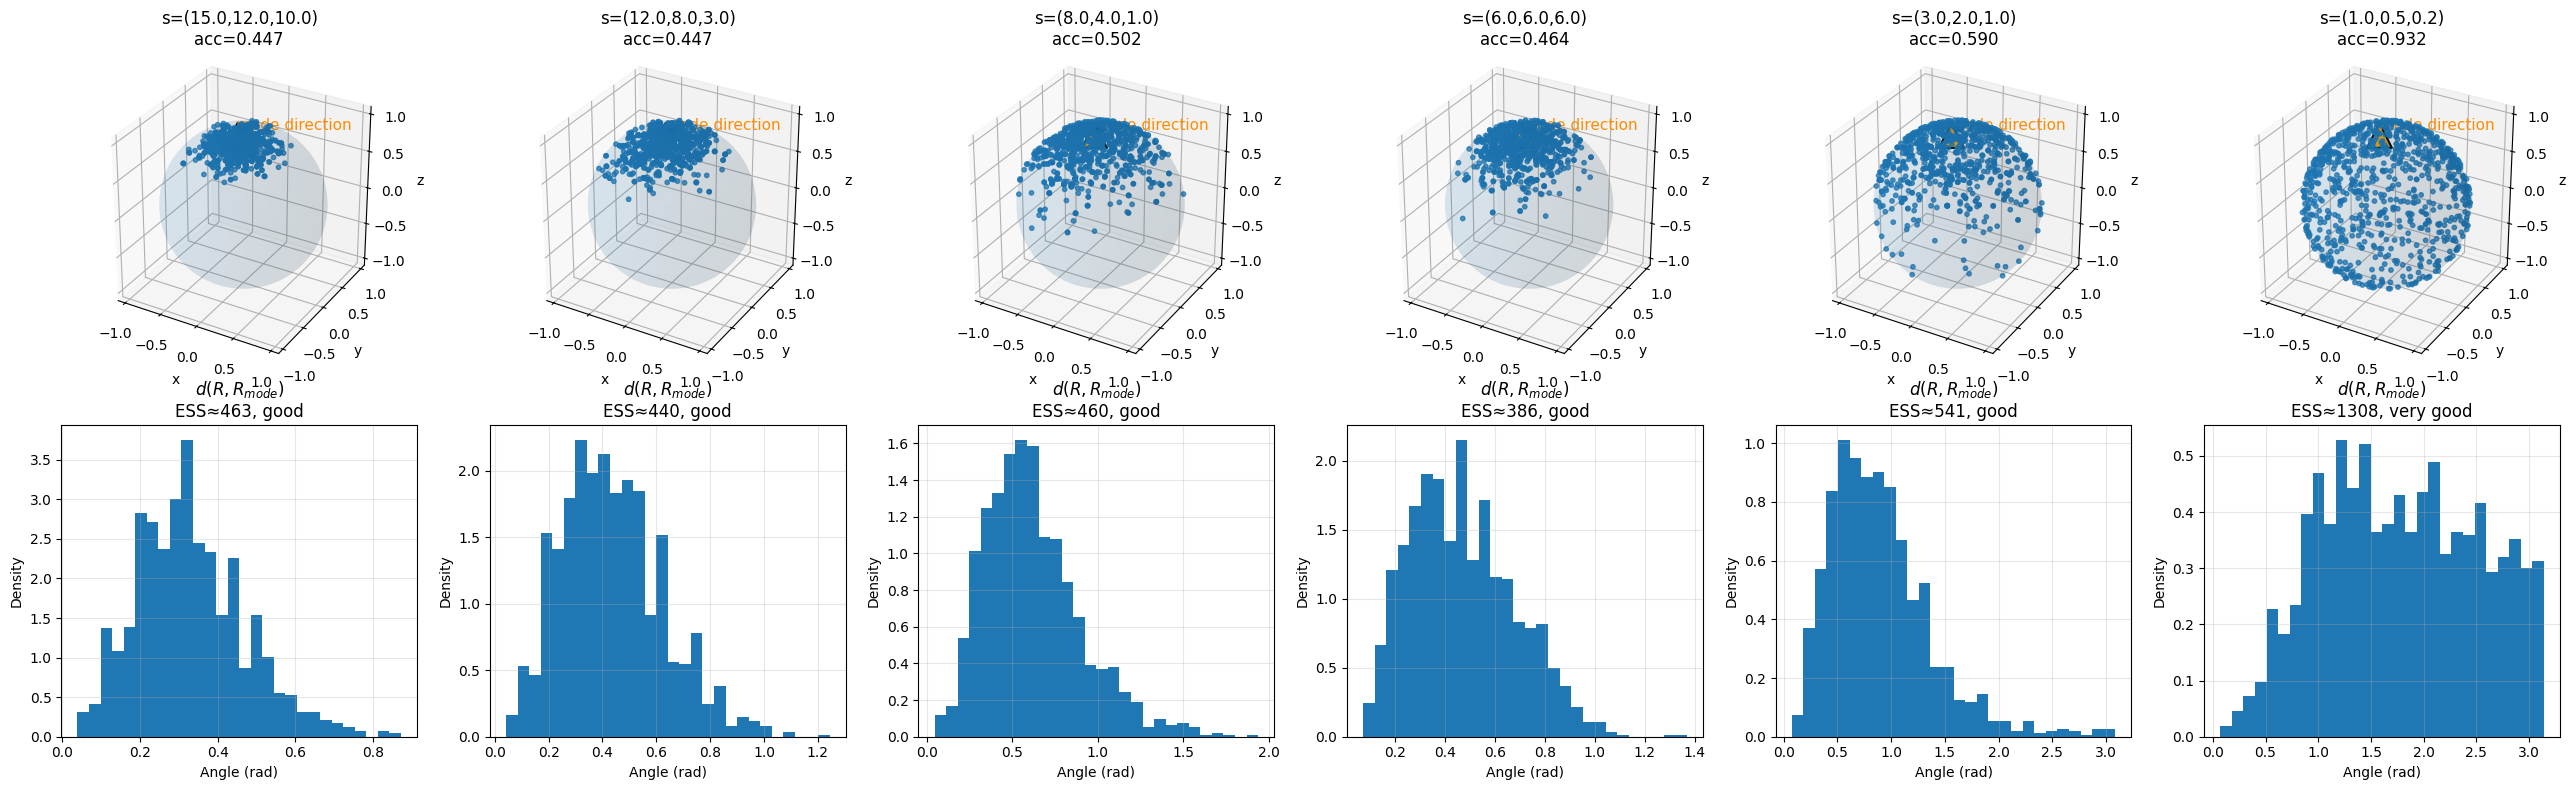


[Part C] Family comparison with random F
Family experiment summary
[Case 1] s=(10.0,7.0,2.0)
  proper-SVD singular values s = [10.  7.  2.]
  acceptance rate            = 0.4459 (good)
  mean d(R, R_mode)         = 0.4683 rad
  std  d(R, R_mode)         = 0.2026 rad
  rough ESS (angle series)  = 460.6
------------------------------------------------------------------------------------------
[Case 2] s=(8.0,8.0,8.0)
  proper-SVD singular values s = [8. 8. 8.]
  acceptance rate            = 0.4588 (good)
  mean d(R, R_mode)         = 0.4113 rad
  std  d(R, R_mode)         = 0.1692 rad
  rough ESS (angle series)  = 477.6
------------------------------------------------------------------------------------------
[Case 3] s=(6.0,3.0,1.0)
  proper-SVD singular values s = [6. 3. 1.]
  acceptance rate            = 0.5424 (good)
  mean d(R, R_mode)         = 0.7028 rad
  std  d(R, R_mode)         = 0.3463 rad
  rough ESS (angle series)  = 581.6
--------------------------------------------------

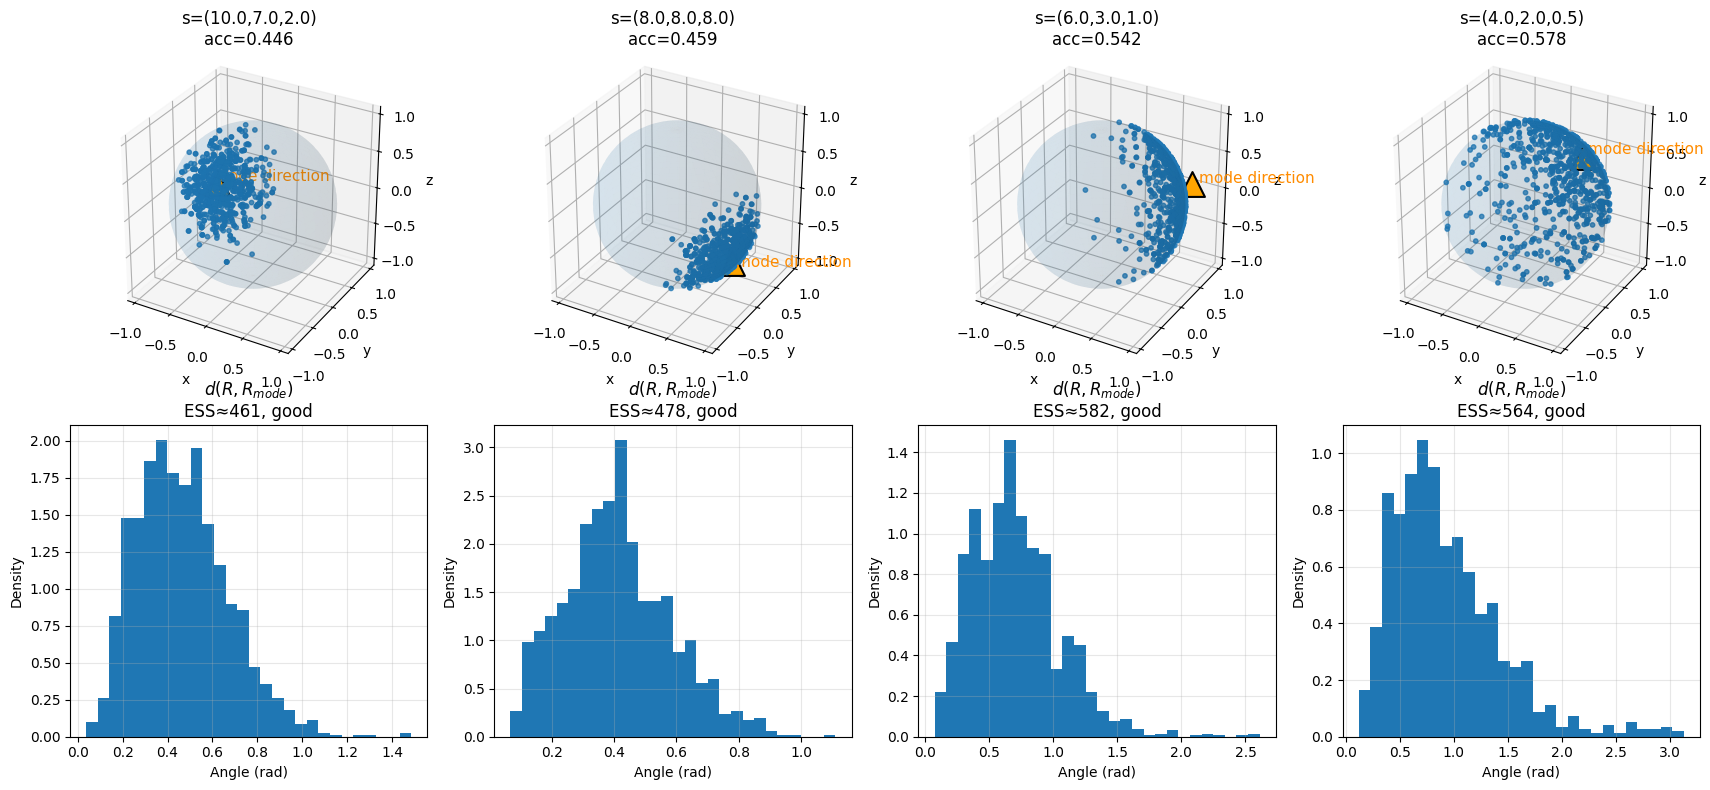

In [7]:
    # --------------------------------------------------------
    # Part B: fixed mode，onlychange s
    # --------------------------------------------------------
    print("\n[Part B] Family comparison with fixed mode")
    s_list_fixed_mode = [
        [15.0, 12.0, 10.0],
        [12.0, 8.0, 3.0],
        [8.0, 4.0, 1.0],
        [6.0, 6.0, 6.0],
        [3.0, 2.0, 1.0],
        [1.0, 0.5, 0.2],
    ]
    global family_fixed
    family_fixed = run_family_experiment(
        s_list=s_list_fixed_mode,
        N=1400,
        burnin=300,
        thin=1,
        c=1.0,
        seed=101,
        randomize_mode=False,
    )

    print_family_summary(family_fixed)
    plot_family_results(family_fixed, vector=np.array([0.0, 0.0, 1.0]), max_points=900)

    # --------------------------------------------------------
    # Part C: random F
    # --------------------------------------------------------
    print("\n[Part C] Family comparison with random F")
    s_list_random = [
        [10.0, 7.0, 2.0],
        [8.0, 8.0, 8.0],
        [6.0, 3.0, 1.0],
        [4.0, 2.0, 0.5],
    ]
    global family_random
    family_random = run_family_experiment(
        s_list=s_list_random,
        N=1400,
        burnin=300,
        thin=1,
        c=1.0,
        seed=202,
        randomize_mode=True,
    )

    print_family_summary(family_random)
    plot_family_results(family_random, vector=np.array([0.0, 0.0, 1.0]), max_points=900)

In [13]:
import numpy as np

def inspect_structure(obj, prefix="root", max_depth=3, depth=0, visited=None):
    if visited is None:
        visited = set()

    oid = id(obj)
    if oid in visited:
        return
    visited.add(oid)

    indent = "  " * depth
    if depth > max_depth:
        print(f"{indent}{prefix}: ...")
        return

    if isinstance(obj, dict):
        print(f"{indent}{prefix}: dict, keys={list(obj.keys())}")
        for k, v in obj.items():
            inspect_structure(v, prefix=f"{prefix}.{k}", max_depth=max_depth, depth=depth+1, visited=visited)

    elif isinstance(obj, (list, tuple)):
        print(f"{indent}{prefix}: {type(obj).__name__}, len={len(obj)}")
        for i, v in enumerate(obj[:3]):   # onlyseebefore3items，avoid spam
            inspect_structure(v, prefix=f"{prefix}[{i}]", max_depth=max_depth, depth=depth+1, visited=visited)

    elif isinstance(obj, np.ndarray):
        print(f"{indent}{prefix}: ndarray, shape={obj.shape}, dtype={obj.dtype}")

    else:
        print(f"{indent}{prefix}: {type(obj).__name__}, value={repr(obj)[:120]}")

print("===== family_fixed structure =====")
inspect_structure(family_fixed, max_depth=3)

===== family_fixed structure =====
root: list, len=6
  root[0]: dict, keys=['F', 'U', 'S', 'V', 's', 'a', 'z', 'K', 'Sigma_g', 'kappa', 'chain_q', 'chain_log_pi', 'accepted_flags', 'stored_q', 'stored_R0', 'stored_R', 'stored_iter', 'acceptance_rate', 'burnin', 'thin', 'N', 'c', 'seed', 'label']
    root[0].F: ndarray, shape=(3, 3), dtype=float64
    root[0].U: ndarray, shape=(3, 3), dtype=float64
    root[0].S: ndarray, shape=(3, 3), dtype=float64
    root[0].V: ndarray, shape=(3, 3), dtype=float64
    root[0].s: ndarray, shape=(3,), dtype=float64
    root[0].a: ndarray, shape=(4,), dtype=float64
    root[0].z: ndarray, shape=(4,), dtype=float64
    root[0].K: ndarray, shape=(4, 4), dtype=float64
    root[0].Sigma_g: ndarray, shape=(4, 4), dtype=float64
    root[0].kappa: ndarray, shape=(4,), dtype=float64
    root[0].chain_q: ndarray, shape=(1701, 4), dtype=float64
    root[0].chain_log_pi: ndarray, shape=(1701,), dtype=float64
    root[0].accepted_flags: ndarray, shape=(1700,), dtyp


[Part A] Single-case visualization
Single-case acceptance rate = 0.4800 (good)


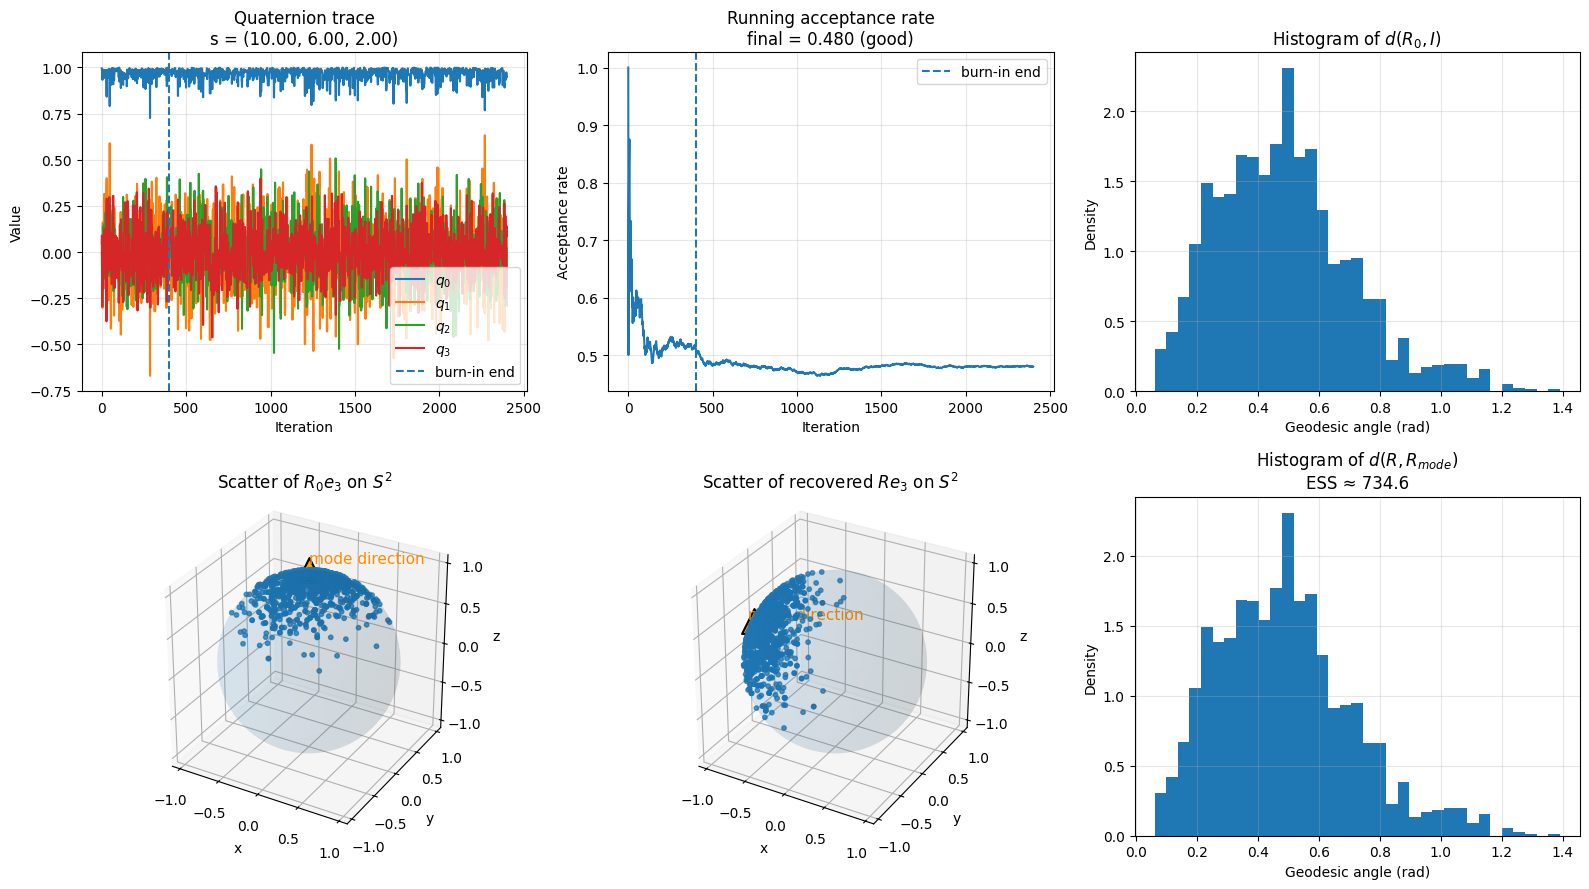

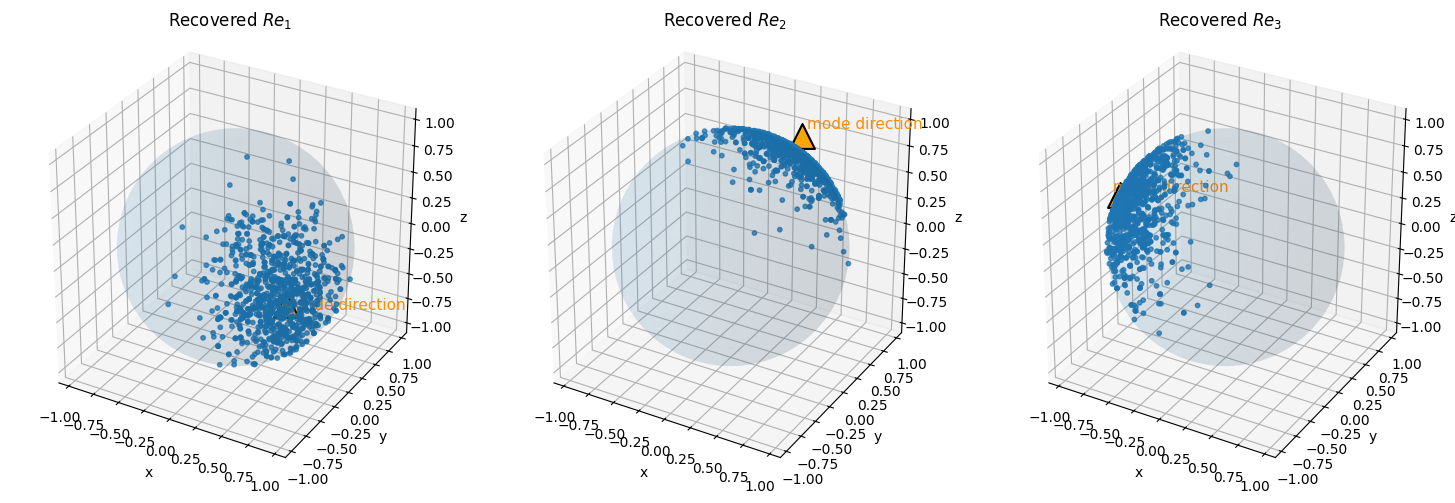

In [14]:
# ============================================================
# ============================================================
if __name__ == "__main__":
    main_family_demo()

 

# Pi-ball for Part B: fixed mode, varying F

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as SciRot

def rotation_matrix_to_rotvec_batch(Rs):
    return SciRot.from_matrix(Rs).as_rotvec()

def relative_rotvecs_from_reference(R_samples, R_ref):
    """
    R_samples: (N,3,3)
    R_ref    : (3,3)
    return   : (N,3) relative rotation vectors log(R_ref^T R)^vee
    """
    R_rel = np.einsum("ij,njk->nik", R_ref.T, R_samples)
    return rotation_matrix_to_rotvec_batch(R_rel)

def plot_family_piball_partB(family_fixed, max_points=700, use_common_reference=True, seed=0):
    rng = np.random.default_rng(seed)
    n_cases = len(family_fixed)

    if use_common_reference:
        R_ref_common = family_fixed[0]["stored_R0"][0]
    else:
        R_ref_common = None

    ncols = 3
    nrows = int(np.ceil(n_cases / ncols))

    fig = plt.figure(figsize=(16, 10))

    # reserve right colorbar andtop title space
    gs = fig.add_gridspec(
        nrows=nrows, ncols=ncols,
        left=0.05, right=0.88, bottom=0.07, top=0.88,
        wspace=0.18, hspace=0.28
    )

    # pi-ball wireframe
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    X = np.pi * np.outer(np.cos(u), np.sin(v))
    Y = np.pi * np.outer(np.sin(u), np.sin(v))
    Z = np.pi * np.outer(np.ones_like(u), np.cos(v))

    scatter_handle = None
    lim = np.pi

    for i, case in enumerate(family_fixed):
        R_samples = case["stored_R"]
        R0_stack  = case["stored_R0"]
        s_vals    = case["s"]
        acc       = case.get("acceptance_rate", None)

        R_ref = R_ref_common if use_common_reference else R0_stack[0]

        if len(R_samples) > max_points:
            idx = rng.choice(len(R_samples), size=max_points, replace=False)
            R_plot = R_samples[idx]
        else:
            R_plot = R_samples

        rv = relative_rotvecs_from_reference(R_plot, R_ref)
        ang = np.linalg.norm(rv, axis=1)

        ax = fig.add_subplot(gs[i // ncols, i % ncols], projection="3d")

        ax.plot_wireframe(X, Y, Z, rstride=3, cstride=3, alpha=0.08)

        scatter_handle = ax.scatter(
            rv[:, 0], rv[:, 1], rv[:, 2],
            c=ang, s=10, alpha=0.82, cmap="viridis"
        )

        # originalpoint / mode
        ax.scatter([0], [0], [0], marker="*", s=120)

        s_text = ", ".join(f"{v:.1f}" for v in np.asarray(s_vals).ravel())
        if acc is not None:
            title_text = f"s = [{s_text}]\nacc = {acc:.3f}"
        else:
            title_text = f"s = [{s_text}]"

        ax.set_title(title_text, pad=8, fontsize=12)

        # ax.set_xlabel(r"$r_1$", labelpad=2)
        # ax.set_ylabel(r"$r_2$", labelpad=2)
        # ax.set_zlabel(r"$r_3$", labelpad=2)

        # ax.set_xlim([-lim, lim])
        # ax.set_ylim([-lim, lim])
        # ax.set_zlim([-lim, lim])
        # ax.set_box_aspect([1, 1, 1])

        ax.set_xlabel(r"$r_1$", labelpad=4)
        ax.set_ylabel(r"$r_2$", labelpad=4)
        ax.set_zlabel(r"$r_3$", labelpad=4)

        ax.set_xlim([-lim, lim])
        ax.set_ylim([-lim, lim])
        ax.set_zlim([-lim, lim])
        ax.set_box_aspect([1, 1, 1])

        tick_vals = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
        tick_labels = [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]

        ax.set_xticks(tick_vals)
        ax.set_yticks(tick_vals)
        ax.set_zticks(tick_vals)

        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_yticklabels(tick_labels, fontsize=9)
        ax.set_zticklabels(tick_labels, fontsize=9)

        ax.view_init(elev=28, azim=-60)



        # viewanglecan slightly unify more comfortably
        ax.view_init(elev=28, azim=-60)

    # place right alone colorbar
    cax = fig.add_axes([0.90, 0.22, 0.018, 0.56])
    #cbar = fig.colorbar(scatter_handle, cax=cax)
    #cbar.set_label("relative rotation angle (rad)", rotation=90, labelpad=10)

    cbar = fig.colorbar(scatter_handle, cax=cax)
    cbar.set_label("relative rotation angle", rotation=90, labelpad=10)

    cb_ticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
    cb_labels = [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
    cbar.set_ticks(cb_ticks)
    cbar.set_ticklabels(cb_labels)



    # fig.suptitle(
    #     r"$\pi$-ball comparison for Part B (fixed mode, varying $F$)$",
    #     fontsize=18,
    #     y=0.95
    # )

    fig.suptitle(
    r"$\pi$-ball comparison for Part B (fixed mode, varying $F$)",
    fontsize=18,
    y=0.95
)

    plt.show()

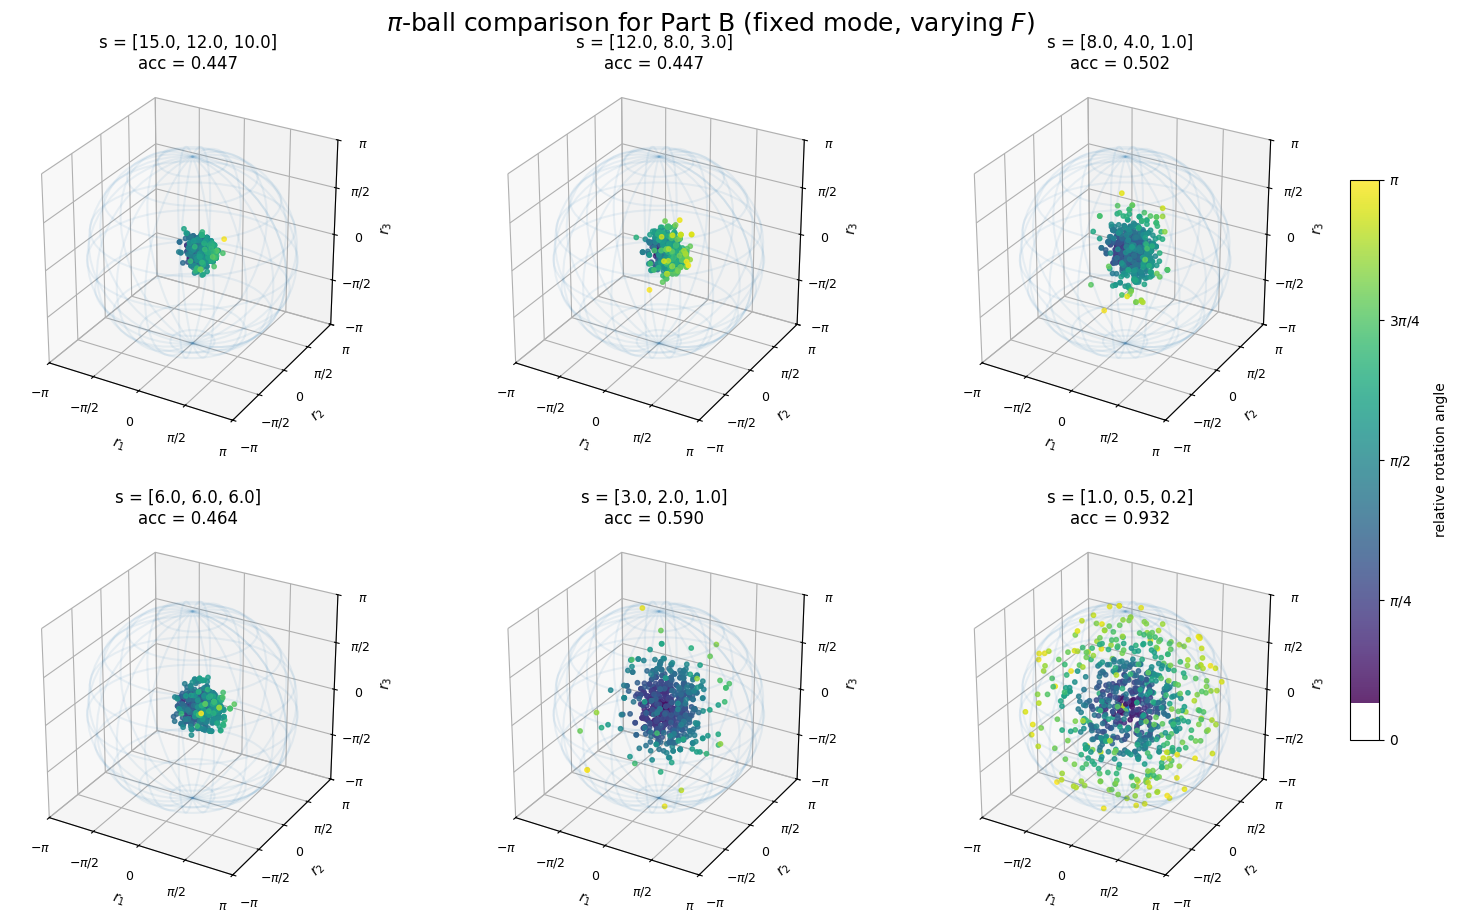

In [25]:
plot_family_piball_partB(
    family_fixed,
    max_points=700,
    use_common_reference=True,
    seed=123
)

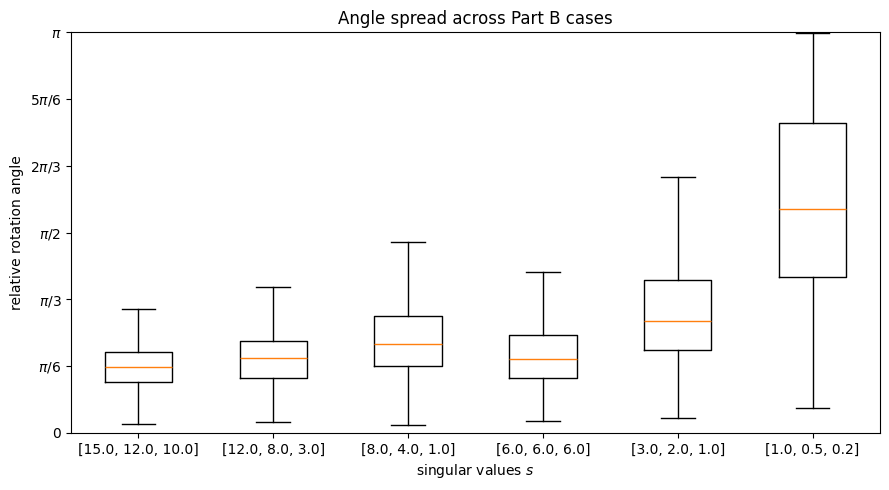

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plot_partB_angle_boxplot(family_fixed, use_common_reference=True):
    if use_common_reference:
        R_ref_common = family_fixed[0]["stored_R0"][0]

    angle_data = []
    labels = []

    for case in family_fixed:
        R_samples = case["stored_R"]
        R_ref = R_ref_common if use_common_reference else case["stored_R0"][0]

        rv = relative_rotvecs_from_reference(R_samples, R_ref)
        ang = np.linalg.norm(rv, axis=1)
        angle_data.append(ang)

        s_vals = case["s"]
        labels.append("[" + ", ".join(f"{v:.1f}" for v in s_vals) + "]")

    plt.figure(figsize=(9, 5))
    plt.boxplot(angle_data, tick_labels=labels, showfliers=False)

    plt.ylabel(r"relative rotation angle")
    plt.xlabel(r"singular values $s$")
    plt.title(r"Angle spread across Part B cases")

    # y-axis ticks in multiples of pi
    # tick_vals = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
    # tick_labels = [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]

    tick_vals = [0, np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6, np.pi]
    tick_labels = [r"$0$", r"$\pi/6$", r"$\pi/3$", r"$\pi/2$", r"$2\pi/3$", r"$5\pi/6$", r"$\pi$"]
    plt.yticks(tick_vals, tick_labels)

    plt.ylim(0, np.pi)
    plt.tight_layout()
    plt.show()

plot_partB_angle_boxplot(family_fixed, use_common_reference=True)

In [29]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 11. Sphere density heatmaps for Re1, Re2, Re3
# ============================================================

def cartesian_to_lon_lat(points: np.ndarray):
    """
    willspherepoint points (N,3) convert to latitude longitude：
        lon in [-pi, pi]
        lat in [-pi/2, pi/2]
    """
    pts = np.asarray(points, dtype=float)
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

    lon = np.arctan2(y, x)
    lat = np.arcsin(np.clip(z, -1.0, 1.0))
    return lon, lat


def spherical_density_histogram(points: np.ndarray, n_lon: int = 72, n_lat: int = 36):
    """
    forspherepointdo areacorrectionafter seconddimensiondensityhistogram。
    return：
        density: shape [n_lat, n_lon]
        lon_edges
        lat_edges
    """
    lon, lat = cartesian_to_lon_lat(points)

    lon_edges = np.linspace(-np.pi, np.pi, n_lon + 1)
    lat_edges = np.linspace(-np.pi / 2, np.pi / 2, n_lat + 1)

    counts, _, _ = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges])

    # areacorrection：spherelat-long grideach bin area with sin(lat2)-sin(lat1) proportionalratio
    area = np.zeros((n_lat, n_lon))
    for i in range(n_lat):
        lat1 = lat_edges[i]
        lat2 = lat_edges[i + 1]
        band_area = (np.sin(lat2) - np.sin(lat1)) * (2 * np.pi / n_lon)
        area[i, :] = band_area

    density = counts / np.maximum(area, 1e-12)
    density = density / np.sum(density)  # normalize tophasefordensity
    return density, lon_edges, lat_edges


def plot_single_axis_heatmap(ax, points: np.ndarray, mode_point: np.ndarray,
                             title: str, n_lon: int = 72, n_lat: int = 36,
                             cmap: str = "viridis"):
    """
    drawsingleaxisdirectionspheredensity heatfigure（latitude longitude expansion）。
    """
    density, lon_edges, lat_edges = spherical_density_histogram(points, n_lon=n_lon, n_lat=n_lat)

    im = ax.pcolormesh(
        lon_edges, lat_edges, density,
        shading="auto",
        cmap=cmap
    )

    # mode direction also convert to lon-lat mark out
    mode_lon, mode_lat = cartesian_to_lon_lat(mode_point.reshape(1, 3))
    ax.scatter(mode_lon, mode_lat, marker="*", s=120, color="red", label="mode direction")

    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-np.pi / 2, np.pi / 2])

    ax.set_xticks(
        [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
        [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
    )
    ax.set_yticks(
        [-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2],
        [r"$-\pi/2$", r"$-\pi/4$", r"$0$", r"$\pi/4$", r"$\pi/2$"]
    )

    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    return im


def visualize_axis_density_heatmaps(results: dict, n_lon: int = 72, n_lat: int = 36,
                                    cmap: str = "viridis"):
    """
    forsingle results draw Re1, Re2, Re3 spheredensity heatfigure。
    """
    stored_R = results["stored_R"]
    U = results["U"]
    V = results["V"]
    s = results["s"]

    R_mode = U @ V.T
    e1 = np.array([1.0, 0.0, 0.0])
    e2 = np.array([0.0, 1.0, 0.0])
    e3 = np.array([0.0, 0.0, 1.0])

    pts1 = apply_rotations_to_vector(stored_R, e1)
    pts2 = apply_rotations_to_vector(stored_R, e2)
    pts3 = apply_rotations_to_vector(stored_R, e3)

    mode1 = R_mode @ e1
    mode2 = R_mode @ e2
    mode3 = R_mode @ e3

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    im1 = plot_single_axis_heatmap(
        axes[0], pts1, mode1,
        title=rf"Density heatmap of $R e_1$, $s=({s[0]:.1f},{s[1]:.1f},{s[2]:.1f})$",
        n_lon=n_lon, n_lat=n_lat, cmap=cmap
    )
    im2 = plot_single_axis_heatmap(
        axes[1], pts2, mode2,
        title=rf"Density heatmap of $R e_2$",
        n_lon=n_lon, n_lat=n_lat, cmap=cmap
    )
    im3 = plot_single_axis_heatmap(
        axes[2], pts3, mode3,
        title=rf"Density heatmap of $R e_3$",
        n_lon=n_lon, n_lat=n_lat, cmap=cmap
    )

    
def compare_re3_density_heatmaps_across_family(family_results, n_lon: int = 72, n_lat: int = 36,
                                               cmap: str = "viridis"):
    """
    for family_results doforratio：onlydraw Re3 density heatfigure，convenientratiocomparedifferentparameterunderdistributionvariation。
    """
    m = len(family_results)
    fig, axes = plt.subplots(1, m, figsize=(4.5 * m, 4.2))

    if m == 1:
        axes = [axes]
    global ims
    ims = []
    e3 = np.array([0.0, 0.0, 1.0])

    for ax, res in zip(axes, family_results):
        stored_R = res["stored_R"]
        U = res["U"]
        V = res["V"]
        s = res["s"]
        acc = res["acceptance_rate"]

        R_mode = U @ V.T
        pts3 = apply_rotations_to_vector(stored_R, e3)
        mode3 = R_mode @ e3

        im = plot_single_axis_heatmap(
            ax, pts3, mode3,
            title=f"s=({s[0]:.1f},{s[1]:.1f},{s[2]:.1f})\nacc={acc:.3f}",
            n_lon=n_lon, n_lat=n_lat, cmap=cmap
        )
        ims.append(im)

    # share colorbar
    from matplotlib.lines import Line2D

    legend_handle = Line2D(
        [0], [0],
        marker='*',
        color='w',
        markerfacecolor='red',
        markersize=14,
        linestyle='None',
        label='mode direction'
    )

    fig.legend(
        handles=[legend_handle],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=1,
        frameon=True
    )

    cbar = fig.colorbar(ims[-1], ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
    cbar.set_label("relative density")



    
    #plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    from matplotlib.lines import Line2D

    legend_handle = Line2D(
        [0], [0],
        marker='*',
        color='w',
        markerfacecolor='red',
        markersize=14,
        linestyle='None',
        label='mode direction'
    )

    fig.legend(
        handles=[legend_handle],
        loc='upper center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=1,
        frameon=True
    )

    cbar = fig.colorbar(ims[-1], ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
    cbar.set_label("relative density")


    #plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [ ]:
visualize_axis_density_heatmaps(res_single, n_lon=72, n_lat=36, cmap="viridis")

In [ ]:
compare_re3_density_heatmaps_across_family(family_fixed, n_lon=72, n_lat=36, cmap="viridis")

In [ ]:
compare_re3_density_heatmaps_across_family(family_random, n_lon=72, n_lat=36, cmap="viridis")

In [30]:
# ============================================================
# 10. Log-map / tangent-space visualization around R_mode
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def hat(v: np.ndarray) -> np.ndarray:
    """
    hat map: R^3 -> so(3)
    """
    v = np.asarray(v, dtype=float).reshape(3)
    return np.array([
        [0.0,   -v[2],  v[1]],
        [v[2],   0.0,  -v[0]],
        [-v[1],  v[0],  0.0]
    ])


def vee(M: np.ndarray) -> np.ndarray:
    """
    vee map: so(3) -> R^3
    """
    return np.array([
        M[2, 1],
        M[0, 2],
        M[1, 0]
    ], dtype=float)


def project_to_so3(R: np.ndarray) -> np.ndarray:
    """
    numericalonwillaclose SO(3) matrixproject back SO(3)。
    """
    U, _, Vt = np.linalg.svd(R)
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0:
        U[:, -1] *= -1.0
        R_proj = U @ Vt
    return R_proj


def log_map_so3(R: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """
    calculate SO(3) onphaseforatunitmatrix log-map:
        xi = log(R)^vee in R^3

    return rotation vector xi，satisfy ||xi|| = rotation angle.
    forat current Matrix-Fisher samplethis，this implementation is sufficientrobust。

    numerical strategy：
    - smallangleuse first order approximation
    - generalangleuse standardformula
    - close pi when useforangleelement recoveryrotationaxis
    """
    R = project_to_so3(R)

    tr = np.trace(R)
    cos_theta = (tr - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    # smallangleapproximation
    if theta < 1e-7:
        return vee(0.5 * (R - R.T))

    # close pi stable handling
    if np.pi - theta < 1e-5:
        # fromforangleelement recoveryaxisdirection
        A = (R + np.eye(3)) / 2.0
        axis = np.zeros(3)

        axis[0] = np.sqrt(max(A[0, 0], 0.0))
        axis[1] = np.sqrt(max(A[1, 1], 0.0))
        axis[2] = np.sqrt(max(A[2, 2], 0.0))

        # use nonforangleelement determines sign
        if R[2, 1] - R[1, 2] < 0:
            axis[0] = -axis[0]
        if R[0, 2] - R[2, 0] < 0:
            axis[1] = -axis[1]
        if R[1, 0] - R[0, 1] < 0:
            axis[2] = -axis[2]

        norm_axis = np.linalg.norm(axis)
        if norm_axis < eps:
            # fallback
            axis = np.array([1.0, 0.0, 0.0])
        else:
            axis = axis / norm_axis

        return theta * axis

    # general case
    Omega = (R - R.T) / (2.0 * np.sin(theta))
    return theta * vee(Omega)


def tangent_vectors_about_mode(Rs: np.ndarray, R_mode: np.ndarray) -> np.ndarray:
    """
    for batch rotationssamplethis Rs，calculatephaseforat mode  log-map:
        xi_i = log(R_mode^T R_i)^vee

    input:
        Rs: shape [N, 3, 3]
        R_mode: shape [3, 3]

    output:
        Xi: shape [N, 3]
    """
    Xi = []
    for R in Rs:
        R_rel = R_mode.T @ R
        xi = log_map_so3(R_rel)
        Xi.append(xi)
    return np.asarray(Xi, dtype=float)


def covariance_ellipse_params(X2: np.ndarray, n_std: float = 2.0):
    """
    fortwodimensionpointcloud X2 (N x 2)，calculatecovarianceellipseparameter：
    ellipseincenter、width、height、rotationangledegree。
    """
    mu = np.mean(X2, axis=0)
    C = np.cov(X2.T)

    eigvals, eigvecs = np.linalg.eigh(C)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    width = 2.0 * n_std * np.sqrt(max(eigvals[0], 0.0))
    height = 2.0 * n_std * np.sqrt(max(eigvals[1], 0.0))
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    return mu, width, height, angle, C, eigvals, eigvecs


def plot_tangent_space_3d(Xi: np.ndarray, title: str = None, max_points: int = 2500):
    """
    figure 1：log-map after 3D tangent-space scatter
    """
    Xi_plot = Xi.copy()
    if Xi_plot.shape[0] > max_points:
        idx = np.linspace(0, Xi_plot.shape[0] - 1, max_points).astype(int)
        Xi_plot = Xi_plot[idx]

    fig = plt.figure(figsize=(7.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(Xi_plot[:, 0], Xi_plot[:, 1], Xi_plot[:, 2], s=10, alpha=0.75)
    ax.scatter([0], [0], [0], s=100, marker="*", label=r"mode ($\xi=0$)")
    ax.legend()

    ax.set_xlabel(r"$\xi_1$")
    ax.set_ylabel(r"$\xi_2$")
    ax.set_zlabel(r"$\xi_3$")

    if title is None:
        title = r"3D tangent-space scatter of $\xi_i=\log(R_{\mathrm{mode}}^\top R_i)^\vee$"
    ax.set_title(title)

    # auto set coordinate range
    lim = np.max(np.abs(Xi_plot)) * 1.1
    lim = max(lim, 0.5)
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    ax.set_box_aspect((1, 1, 1))

    # lim = np.pi
    # ax.set_xlim([-lim, lim])
    # ax.set_ylim([-lim, lim])
    # ax.set_zlim([-lim, lim])

    plt.tight_layout()
    plt.show()


def plot_tangent_pairwise(Xi: np.ndarray, n_std: float = 2.0, max_points: int = 2500):
    """
    figure 2：pairwise 2D tangent-space scatter + covariance ellipse
    show anisotropy most intuitive。
    """
    Xi_plot = Xi.copy()
    if Xi_plot.shape[0] > max_points:
        idx = np.linspace(0, Xi_plot.shape[0] - 1, max_points).astype(int)
        Xi_plot = Xi_plot[idx]

    pairs = [(0, 1), (0, 2), (1, 2)]
    labels = [
        (r"$\xi_1$", r"$\xi_2$"),
        (r"$\xi_1$", r"$\xi_3$"),
        (r"$\xi_2$", r"$\xi_3$")
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

    for ax, (i, j), (lx, ly) in zip(axes, pairs, labels):
        X2 = Xi_plot[:, [i, j]]

        ax.scatter(X2[:, 0], X2[:, 1], s=10, alpha=0.55)
        ax.scatter([0], [0], s=80, marker="*", label="mode")

        mu, width, height, angle, C, eigvals, eigvecs = covariance_ellipse_params(X2, n_std=n_std)

        # drawempiricalmeanpoint
        ax.scatter([mu[0]], [mu[1]], s=40, marker="x", label="empirical mean")

        # drawcovarianceellipse
        ell = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            fill=False,
            linewidth=2.0
        )
        ax.add_patch(ell)

        ax.set_xlabel(lx)
        ax.set_ylabel(ly)
        ax.set_title(
            f"{lx} vs {ly}\n"
            f"eig std ≈ ({np.sqrt(eigvals[0]):.3f}, {np.sqrt(eigvals[1]):.3f})"
        )
        ax.grid(True, alpha=0.3)
        ax.axis("equal")
        ax.legend()

    fig.suptitle(r"Pairwise tangent-space scatter with covariance ellipses", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


def summarize_tangent_cloud(Xi: np.ndarray):
    """
    output tangent cloud statistical summary，for explaining anisotropy。
    """
    mu = np.mean(Xi, axis=0)
    C = np.cov(Xi.T)
    eigvals, eigvecs = np.linalg.eigh(C)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    print("=" * 72)
    print("Tangent-space summary around R_mode")
    print("=" * 72)
    print("Empirical mean of xi:")
    print(mu)
    print("\nEmpirical covariance of xi:")
    print(C)
    print("\nEigenvalues of covariance (descending):")
    print(eigvals)
    print("\nCorresponding principal directions (columns):")
    print(eigvecs)
    print("=" * 72)


def visualize_tangent_space_for_results(results: dict, max_points: int = 2500):
    """
    forsome existingsampleresult results（namely sample_mf_so3_independence_mh output）
    directgenerate log-map / tangent-space visualize。
    """
    Rs = results["stored_R"]
    U = results["U"]
    V = results["V"]
    s = results["s"]

    R_mode = U @ V.T
    Xi = tangent_vectors_about_mode(Rs, R_mode)

    print(f"\nTangent-space visualization for s = ({s[0]:.2f}, {s[1]:.2f}, {s[2]:.2f})")
    summarize_tangent_cloud(Xi)

    plot_tangent_space_3d(
        Xi,
        title=rf"3D tangent-space scatter around $R_{{\mathrm{{mode}}}}$, "
              rf"$s=({s[0]:.1f},{s[1]:.1f},{s[2]:.1f})$",
        max_points=max_points
    )
    plot_tangent_pairwise(Xi, n_std=2.0, max_points=max_points)

    return Xi


def compare_tangent_space_across_family(family_results, max_points: int = 1800):
    """
    fora group family_results do androwforratio：
    each case drawa xi1-xi2 planefigure（withcovarianceellipse），
    convenient directratiocompare anisotropy / concentration variation。
    """
    m = len(family_results)
    fig, axes = plt.subplots(1, m, figsize=(4.3 * m, 4.6))

    if m == 1:
        axes = [axes]

    for ax, res in zip(axes, family_results):
        Rs = res["stored_R"]
        U = res["U"]
        V = res["V"]
        s = res["s"]
        R_mode = U @ V.T

        Xi = tangent_vectors_about_mode(Rs, R_mode)
        if Xi.shape[0] > max_points:
            idx = np.linspace(0, Xi.shape[0] - 1, max_points).astype(int)
            Xi = Xi[idx]

        X2 = Xi[:, [0, 1]]
        ax.scatter(X2[:, 0], X2[:, 1], s=10, alpha=0.5)
        ax.scatter([0], [0], s=70, marker="*", label="mode")

        mu, width, height, angle, C, eigvals, eigvecs = covariance_ellipse_params(X2, n_std=2.0)
        ell = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            fill=False,
            linewidth=2.0
        )
        ax.add_patch(ell)

        ax.set_title(
            f"s=({s[0]:.1f},{s[1]:.1f},{s[2]:.1f})\n"
            f"std≈({np.sqrt(eigvals[0]):.2f},{np.sqrt(eigvals[1]):.2f})"
        )
        ax.set_xlabel(r"$\xi_1$")
        ax.set_ylabel(r"$\xi_2$")
        ax.grid(True, alpha=0.3)
        ax.axis("equal")
        ax.legend()

    fig.suptitle(r"Tangent-space comparison across different Matrix--Fisher parameters", y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
#'res_single' in globals()

In [ ]:
#%whos

In [ ]:
Xi_single = visualize_tangent_space_for_results(res_single, max_points=2000)

In [31]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_kde_1d(samples: np.ndarray, grid: np.ndarray, bandwidth: float = None):
    """
    anot depend on scipy simple 1D Gaussian KDE.
    samples: shape [N]
    grid: shape [M]
    """
    x = np.asarray(samples, dtype=float).ravel()
    n = len(x)
    if n < 2:
        return np.zeros_like(grid)

    std = np.std(x, ddof=1)
    if bandwidth is None:
        # Silverman's rule of thumb
        bandwidth = 1.06 * std * (n ** (-1 / 5))
        bandwidth = max(bandwidth, 1e-3)

    diff = grid[:, None] - x[None, :]
    vals = np.exp(-0.5 * (diff / bandwidth) ** 2) / (np.sqrt(2 * np.pi) * bandwidth)
    density = np.mean(vals, axis=1)
    return density


def plot_family_angle_density_curves(
    family_results,
    use_mode_distance: bool = True,
    num_grid: int = 300,
    bandwidth: float = None,
    title: str = None
):
    """
    will family_results ineach case angledistancedistributionmergetoa smooth density curvefigurein。

    use_mode_distance=True:
        draw d(R, R_mode)
    use_mode_distance=False:
        draw d(R0, I)
    """
    all_angles = []

    for res in family_results:
        if use_mode_distance:
            U = res["U"]
            V = res["V"]
            R_mode = U @ V.T
            angles = np.array([geodesic_distance_so3(R, R_mode) for R in res["stored_R"]])
        else:
            angles = np.array([geodesic_distance_so3(R0, np.eye(3)) for R0 in res["stored_R0"]])
        all_angles.append(angles)

    max_angle = max(np.max(a) for a in all_angles)
    grid = np.linspace(0.0, max_angle * 1.05, num_grid)

    plt.figure(figsize=(8.5, 5.5))

    for res, angles in zip(family_results, all_angles):
        s = res["s"]
        label = f"s=({s[0]:.1f},{s[1]:.1f},{s[2]:.1f})"
        dens = gaussian_kde_1d(angles, grid, bandwidth=bandwidth)
        plt.plot(grid, dens, linewidth=2, label=label)

    xlabel = r"$\theta = d(R,R_{\mathrm{mode}})$ (rad)" if use_mode_distance else r"$\theta = d(R_0,I)$ (rad)"
    if title is None:
        title = "Smoothed angle-density comparison across cases"

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

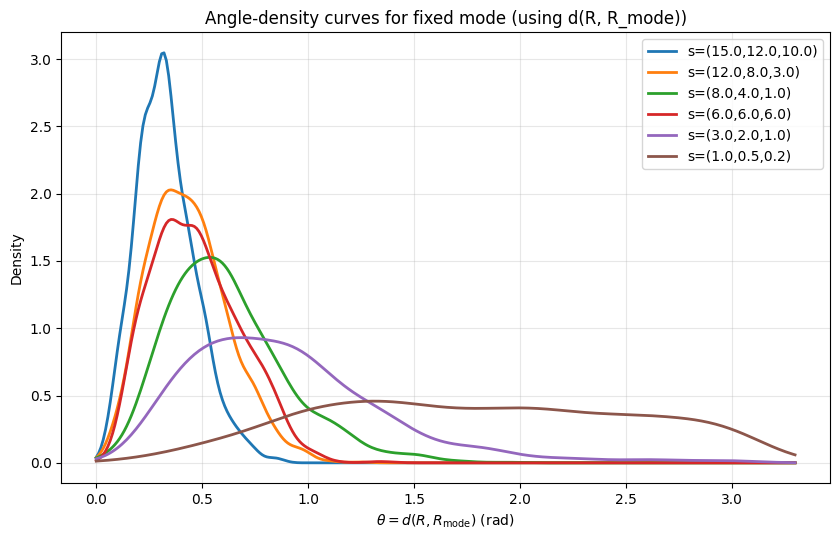

In [32]:
####fix mode
plot_family_angle_density_curves(
    family_fixed,
    use_mode_distance=True,
    title="Angle-density curves for fixed mode (using d(R, R_mode))"
)

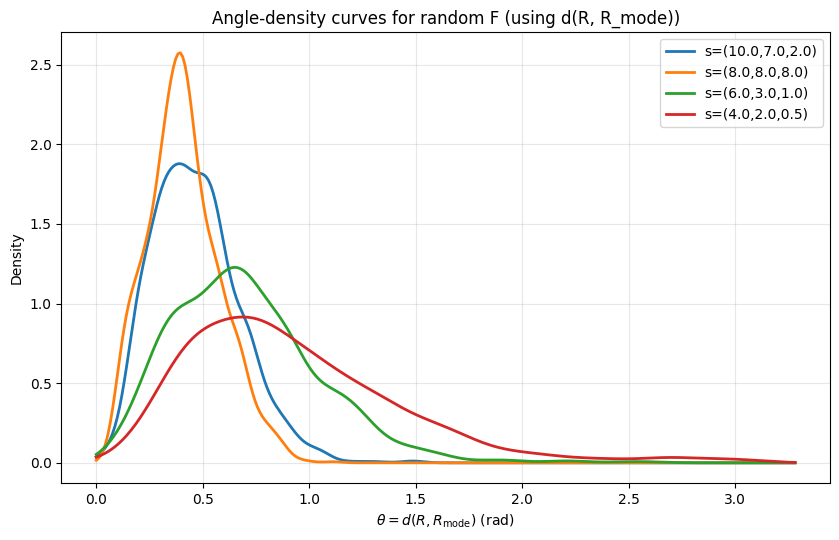

In [33]:
#### random F : family 
plot_family_angle_density_curves(
    family_random,
    use_mode_distance=True,
    title="Angle-density curves for random F (using d(R, R_mode))"
)